# Prática: Workflow de ML e Regressão Linear
# Insper AI

---

Este notebook é a **atividade guiada** da aula 01.

- O handout concentra a **teoria** da regressão linear e do workflow de ML.
- Este notebook concentra a **prática**: explorar dados, investigar outliers, treinar um baseline e comparar resultados antes e depois de uma limpeza simples.

Antes de começar, vale ter o handout aberto em outra aba:

- [Handout](https://insperai-trainee.github.io/InsperAI26.1/aula-01/)

## Objetivo

Treinar um modelo baseline de regressão linear no **California Housing Dataset** e medir o impacto de remover dados suspeitos.

## Fluxo da atividade

1. Carregar e inspecionar os dados
2. Fazer uma EDA curta
3. Investigar dois problemas centrais do dataset
4. Treinar um modelo baseline
5. Avaliar com `R²`, `RMSE` e `MAE`
6. Limpar dados suspeitos e comparar os resultados


## Antes de começar

Rode para sincronizar as dependências:

```bash
uv sync
```

## Começando: importando bibliotecas e carregando os dados

Nesta prática vamos usar `pandas`, `numpy`, `matplotlib`, `seaborn` e utilitários do `scikit-learn`.

O dataset será carregado diretamente do `sklearn.datasets.fetch_california_housing(as_frame=True)`.

In [1]:
# Importações principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregamento do dataset
california = fetch_california_housing(as_frame=True)
df = california.frame.copy()

print(f"Dataset carregado com {df.shape[0]:,} linhas e {df.shape[1]:,} colunas")
df.head()


Dataset carregado com 20,640 linhas e 9 colunas


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Inspeção inicial

**Tarefa 1.1:** entenda a estrutura básica do dataset.

Nesta primeira parte, o código já está pronto. Execute a célula abaixo e foque na leitura das saídas.

**Responda:**
- Há valores faltantes?
- Quais colunas já parecem ter valores extremos?
- Qual coluna é o target da regressão?


In [2]:
# Inspeção inicial pronta
df.head()
df.info()
df.describe().T.round(2)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,20640.0,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,20640.0,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveOccup,20640.0,3.07,10.39,0.69,2.43,2.82,3.28,1243.33
Latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,20640.0,2.07,1.15,0.15,1.20,1.80,2.65,5.00


## 2. EDA curta

Agora a ideia não é fazer uma análise exaustiva, e sim levantar os sinais mais importantes para o restante da aula.

Nesta parte, o código dos gráficos já está pronto. O foco aqui é **ler os gráficos** e começar a perceber os outliers e dados suspeitos.

**Tarefa 2.1:** execute a célula abaixo e use as visualizações para responder estas perguntas:

- Como o target `MedHouseVal` está distribuído?
- `AveOccup` e `AveRooms` parecem ter valores suspeitos?
- Onde estão os blocos mais caros no mapa da Califórnia?


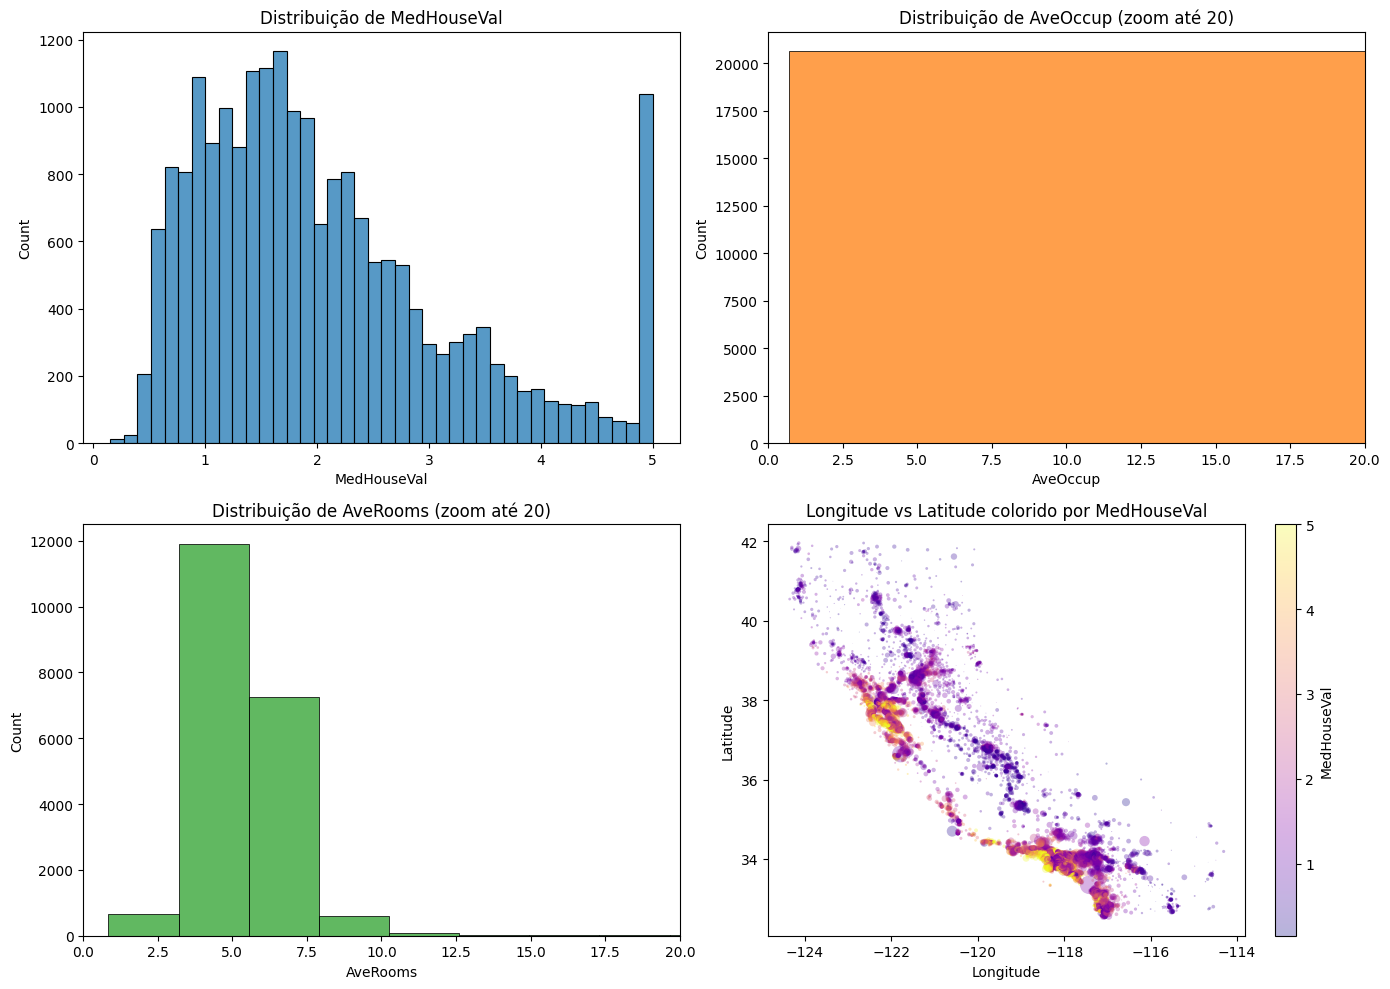

In [3]:
# EDA pronta: execute e foque na interpretação dos gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Histograma de MedHouseVal
sns.histplot(df, x="MedHouseVal", bins=40, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Distribuição de MedHouseVal")

# 2) Histograma de AveOccup
sns.histplot(df, x="AveOccup", bins=60, ax=axes[0, 1], color="#ff7f0e")
axes[0, 1].set_xlim(0, 20)
axes[0, 1].set_title("Distribuição de AveOccup (zoom até 20)")

# 3) Histograma de AveRooms
sns.histplot(df, x="AveRooms", bins=60, ax=axes[1, 0], color="#2ca02c")
axes[1, 0].set_xlim(0, 20)
axes[1, 0].set_title("Distribuição de AveRooms (zoom até 20)")

# 4) Mapa geográfico colorido pelo target
sc = axes[1, 1].scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="plasma",
    alpha=0.3,
    s=df["Population"] / 200,
    linewidths=0,
)
axes[1, 1].set_title("Longitude vs Latitude colorido por MedHouseVal")
axes[1, 1].set_xlabel("Longitude")
axes[1, 1].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[1, 1], label="MedHouseVal")

plt.tight_layout()
plt.show()


**Tarefa 2.2:** olhe para as correlações com o target.

Aqui também vamos deixar o código pronto. O objetivo não é praticar sintaxe de `pandas`, e sim interpretar quais features parecem mais associadas ao preço.

Depois de executar a célula abaixo, responda:

1. Quais features parecem mais relevantes para prever `MedHouseVal`?
2. Alguma correlação te surpreendeu?
3. Correlação fraca significa feature inútil?


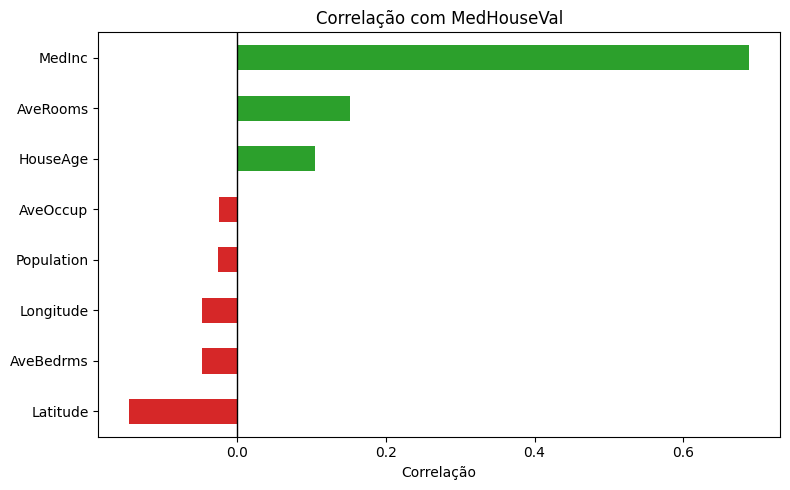

In [4]:
# Correlações prontas: execute e interprete
corr_target = df.corr(numeric_only=True)["MedHouseVal"].drop("MedHouseVal")
corr_target = corr_target.loc[corr_target.abs().sort_values(ascending=False).index]
corr_target.to_frame(name="correlacao")

plt.figure(figsize=(8, 5))
cores = np.where(corr_target.sort_values().values >= 0, "#2ca02c", "#d62728")
corr_target.sort_values().plot(kind="barh", color=cores)
plt.title("Correlação com MedHouseVal")
plt.xlabel("Correlação")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()


## 3. Investigando dados suspeitos

Nesta aula vamos focar em dois problemas centrais do dataset:

- `MedHouseVal == 5.0`: preço censurado no teto de USD 500k
- `AveOccup > 20`: blocos com ocupação média improvável para residências comuns

**Dica breve:** nesta etapa, pense em **máscaras booleanas** no `pandas`. Para contar casos, procure operações como `.sum()` sobre condições booleanas. Para inspecionar extremos, vale buscar métodos como `.nlargest(...)` ou `.sort_values(...).head(...)`.

Se precisar de contexto, volte para [Outliers e Dados Suspeitos](https://insperai-trainee.github.io/InsperAI26.1/aula-01/outliers/).


In [5]:
n_teto = (df["MedHouseVal"] == 5.0).sum()
n_occup_extrema = (df["AveOccup"] > 20).sum()

colunas_inspecao = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population",
    "AveOccup",
    "Latitude",
    "Longitude",
    "MedHouseVal",
]
top_aveoccup = df.nlargest(10, "AveOccup")[colunas_inspecao]
suspeitos = df.loc[df["AveOccup"] > 20].copy()

print(f"Linhas com MedHouseVal == 5.0: {n_teto}")
print(f"Linhas com AveOccup > 20: {n_occup_extrema}")
print(f"DataFrame suspeitos criado com {suspeitos.shape[0]} linhas.")

display(top_aveoccup)


Linhas com MedHouseVal == 5.0: 27
Linhas com AveOccup > 20: 10
DataFrame suspeitos criado com 10 linhas.


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.37500
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.67500
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.50000
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.25000
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.54600
12104,1.6250,8.0,7.600000,0.950000,1275.0,63.750000,33.97,-117.33,1.62500
16420,5.7485,26.0,5.366667,0.900000,1542.0,51.400000,37.89,-121.29,1.62500
8874,9.3370,52.0,7.285714,1.214286,1154.0,41.214286,34.06,-118.45,5.00001
13366,4.2578,36.0,5.258824,1.117647,2886.0,33.952941,33.94,-117.63,1.83300
5986,1.8750,52.0,4.500000,1.206349,2688.0,21.333333,34.10,-117.71,2.12500


**Reflita antes de seguir:**

- O teto em `MedHouseVal` atrapalha a regressão? Por quê?
- Faz sentido considerar blocs com `AveOccup = 30`, `80` ou `200` **para esse problema**? Por quê?
- Esses pontos devem ser removidos sempre, ou isso depende do objetivo do modelo?


## 4. Preparação dos dados

Primeiro vamos treinar um **baseline com os dados brutos**.
A ideia é medir a performance original antes de qualquer limpeza.

**Dica breve:** aqui o padrão costuma ser separar o target das features e depois usar `train_test_split(...)` para criar conjuntos de treino e teste.


In [6]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X: (20640, 8)
y: (20640,)
X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


## 5. Treino do modelo baseline

Lembrete curto: a regressão linear aprende uma relação do tipo `ŷ = w^T x + b`, escolhendo coeficientes que minimizam o erro quadrático no treino.

Se essa frase não estiver clara, volte ao handout antes de continuar.

**Dica breve:** o fluxo aqui é sempre o mesmo: instanciar o modelo, chamar `.fit(...)` com os dados de treino e depois inspecionar atributos do modelo treinado.


In [7]:
model_bruto = LinearRegression()
model_bruto.fit(X_train, y_train)

print(f"Intercepto (bruto): {model_bruto.intercept_:.4f}")

coef_brutos = pd.DataFrame(
    {
        "feature": X_train.columns,
        "coeficiente": model_bruto.coef_,
    }
)
coef_brutos = (
    coef_brutos.assign(coef_abs=coef_brutos["coeficiente"].abs())
    .sort_values("coef_abs", ascending=False)
    .drop(columns="coef_abs")
    .reset_index(drop=True)
)

coef_brutos


Intercepto (bruto): -37.0233


,feature,coeficiente
0,AveBedrms,0.783145
1,MedInc,0.448675
2,Longitude,-0.433708
3,Latitude,-0.419792
4,AveRooms,-0.123323
5,HouseAge,0.009724
6,AveOccup,-0.003526
7,Population,-0.000002


## 6. Avaliação do baseline

**Tarefa 6.1:** gere previsões e calcule métricas para treino e teste.

Use pelo menos estas métricas:

- `R²`
- `RMSE`
- `MAE`

A organização dessas métricas em um `DataFrame` costuma facilitar a comparação.

**Dica breve:** primeiro gere previsões com `.predict(...)`. Depois procure as métricas no módulo `sklearn.metrics`.


In [8]:
y_pred_train_bruto = model_bruto.predict(X_train)
y_pred_test_bruto = model_bruto.predict(X_test)

metricas_brutas = pd.DataFrame(
    {
        "R²": [
            r2_score(y_train, y_pred_train_bruto),
            r2_score(y_test, y_pred_test_bruto),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_train, y_pred_train_bruto)),
            np.sqrt(mean_squared_error(y_test, y_pred_test_bruto)),
        ],
        "MAE": [
            mean_absolute_error(y_train, y_pred_train_bruto),
            mean_absolute_error(y_test, y_pred_test_bruto),
        ],
    },
    index=["treino", "teste"],
).round(4)

metricas_brutas


,R²,RMSE,MAE
treino,0.6126,0.7197,0.5286
teste,0.5758,0.7456,0.5332


**Tarefa 6.2:** visualize `valor real vs valor predito` no conjunto de teste.

Procure especialmente por sinais do teto artificial em `MedHouseVal`.

**Dica breve:** um gráfico de dispersão costuma ser suficiente. Para a linha de referência `y = x`, use os limites mínimo e máximo observados.


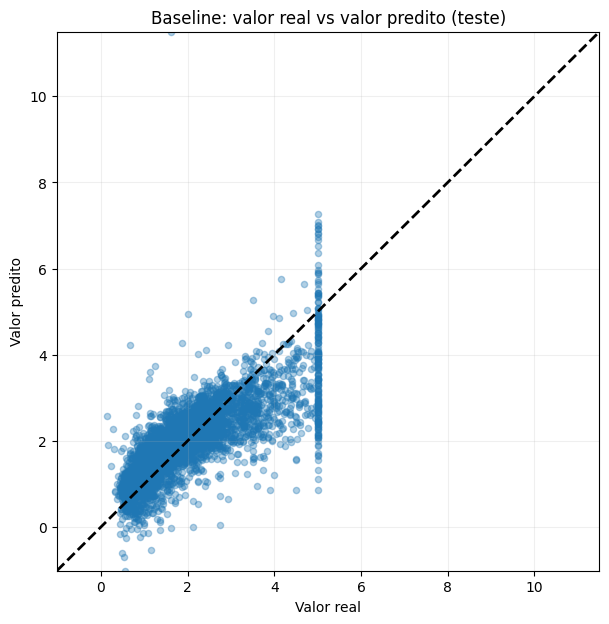

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test_bruto, alpha=0.35, s=20, color="#1f77b4")

lim_min = min(y_test.min(), y_pred_test_bruto.min())
lim_max = max(y_test.max(), y_pred_test_bruto.max())

plt.plot([lim_min, lim_max], [lim_min, lim_max], "--", color="black", linewidth=2)
plt.xlabel("Valor real")
plt.ylabel("Valor predito")
plt.title("Baseline: valor real vs valor predito (teste)")
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)
plt.grid(alpha=0.2)
plt.show()


## 7. Limpando dados suspeitos e treinando de novo

Agora vamos testar uma limpeza simples, inspirada diretamente na página de outliers:

- remover blocos com `MedHouseVal == 5.0`
- remover blocos com `AveOccup > 20`

Não estamos dizendo que essa é a limpeza definitiva; estamos apenas medindo o impacto dela.

**Dica breve:** aqui vale combinar condições booleanas e depois repetir exatamente o mesmo pipeline do baseline.


In [10]:
mask_limpeza = (df["MedHouseVal"] != 5.0) & (df["AveOccup"] <= 20)
df_limpo = df.loc[mask_limpeza].copy()

linhas_removidas = len(df) - len(df_limpo)
print(f"Linhas removidas: {linhas_removidas}")
print(f"Shape original: {df.shape}")
print(f"Shape limpo: {df_limpo.shape}")

X_limpo = df_limpo.drop(columns="MedHouseVal")
y_limpo = df_limpo["MedHouseVal"]

X_train_limpo, X_test_limpo, y_train_limpo, y_test_limpo = train_test_split(
    X_limpo,
    y_limpo,
    test_size=0.2,
    random_state=42,
)

print(f"X_train_limpo: {X_train_limpo.shape}")
print(f"X_test_limpo: {X_test_limpo.shape}")
print(f"y_train_limpo: {y_train_limpo.shape}")
print(f"y_test_limpo: {y_test_limpo.shape}")


Linhas removidas: 37
Shape original: (20640, 9)
Shape limpo: (20603, 9)
X_train_limpo: (16482, 8)
X_test_limpo: (4121, 8)
y_train_limpo: (16482,)
y_test_limpo: (4121,)


In [11]:
model_limpo = LinearRegression()
model_limpo.fit(X_train_limpo, y_train_limpo)

y_pred_train_limpo = model_limpo.predict(X_train_limpo)
y_pred_test_limpo = model_limpo.predict(X_test_limpo)

metricas_limpas = pd.DataFrame(
    {
        "R²": [
            r2_score(y_train_limpo, y_pred_train_limpo),
            r2_score(y_test_limpo, y_pred_test_limpo),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_train_limpo, y_pred_train_limpo)),
            np.sqrt(mean_squared_error(y_test_limpo, y_pred_test_limpo)),
        ],
        "MAE": [
            mean_absolute_error(y_train_limpo, y_pred_train_limpo),
            mean_absolute_error(y_test_limpo, y_pred_test_limpo),
        ],
    },
    index=["treino", "teste"],
).round(4)

coef_limpos = pd.DataFrame(
    {
        "feature": X_train_limpo.columns,
        "coeficiente": model_limpo.coef_,
    }
)
coef_limpos = (
    coef_limpos.assign(coef_abs=coef_limpos["coeficiente"].abs())
    .sort_values("coef_abs", ascending=False)
    .drop(columns="coef_abs")
    .reset_index(drop=True)
)

print(f"Intercepto (limpo): {model_limpo.intercept_:.4f}")
display(metricas_limpas)
display(coef_limpos)


Intercepto (limpo): -34.8542


,R²,RMSE,MAE
treino,0.6472,0.6809,0.4959
teste,0.6382,0.6998,0.4987


,feature,coeficiente
0,AveBedrms,0.628692
1,Latitude,-0.428198
2,MedInc,0.427901
3,Longitude,-0.424506
4,AveOccup,-0.255809
5,AveRooms,-0.096166
6,HouseAge,0.010622
7,Population,0.000031


## 8. Comparando bruto vs limpo

**Tarefa 8.1:** compare os dois modelos lado a lado.

Monte uma tabela final com as métricas do baseline e do modelo treinado após a limpeza.

**Perguntas para responder:**

- O `R²` de teste melhorou?
- O `RMSE` e o `MAE` caíram?
- A limpeza ajudou mais na interpretação do problema ou na métrica em si?

**Dica breve:** antes de interpretar, organize as duas tabelas no mesmo formato. Isso deixa a comparação visual e conceitual mais simples.


In [12]:
comparacao_metricas = pd.concat(
    {
        "bruto": metricas_brutas,
        "limpo": metricas_limpas,
    },
    axis=1,
).round(4)

display(comparacao_metricas)

comparacao_coeficientes = coef_brutos.merge(
    coef_limpos,
    on="feature",
    how="outer",
    suffixes=("_bruto", "_limpo"),
)
comparacao_coeficientes["delta_abs"] = (
    comparacao_coeficientes["coeficiente_limpo"]
    - comparacao_coeficientes["coeficiente_bruto"]
).abs()
comparacao_coeficientes = comparacao_coeficientes.sort_values(
    "delta_abs", ascending=False
).reset_index(drop=True)
comparacao_coeficientes = comparacao_coeficientes.round(4)

display(comparacao_coeficientes.head(10))


bruto                   limpo                
            R²    RMSE     MAE      R²    RMSE     MAE
treino  0.6126  0.7197  0.5286  0.6472  0.6809  0.4959
teste   0.5758  0.7456  0.5332  0.6382  0.6998  0.4987

,feature,coeficiente_bruto,coeficiente_limpo,delta_abs
0,AveOccup,-0.0035,-0.2558,0.2523
1,AveBedrms,0.7831,0.6287,0.1545
2,AveRooms,-0.1233,-0.0962,0.0272
3,MedInc,0.4487,0.4279,0.0208
4,Longitude,-0.4337,-0.4245,0.0092
5,Latitude,-0.4198,-0.4282,0.0084
6,HouseAge,0.0097,0.0106,0.0009
7,Population,-0.0000,0.0000,0.0000


## Desafios extras (opcional)

1. Teste diferentes valores de `test_size` e compare a estabilidade do `R²`.
2. Compare o baseline com uma versão que também remove outliers de `AveRooms`.
3. Plote os resíduos `y_test - y_pred_test` e veja se eles parecem aleatórios.
4. Leia [Leitura Complementar](https://insperai-trainee.github.io/InsperAI26.1/aula-01/complementar/) e compare esse baseline simples com uma análise mais cuidadosa.


## Conclusão

Parabéns se você chegou até aqui. Não esqueça de commitar e dar push nas suas mudanças!